# L9a Advanced: SPXW European Index Options and the Volatility Skew
L9a evaluated Black--Scholes--Merton (BSM) with one volatility input. A market option chain reverses that calculation: every quoted European premium implies the volatility that makes the model reproduce that quote. The resulting cross-section is not flat for index options; downside strikes commonly carry higher implied volatility than upside strikes.

This notebook uses SPXW contract conventions to turn the abstract European payoff into a concrete index product. SPX-family options are European exercise and cash settled; SPXW expirations are generally PM settled, and one index point corresponds to 100 USD per contract. See the [Cboe SPX product page](https://www.cboe.com/tradable-products/sp-500/spx-options/) and [contract specifications](https://www.cboe.com/tradable-products/sp-500/spx-options/spx-specifications/).

> __Learning Objectives:__
>
> By the end of this notebook, you should be able to:
> * __Recover financing inputs from put--call parity.__ Estimate a discount factor and forward index level from matched European call and put quotes rather than assuming spot carry inputs.
> * __Invert BSM premiums for implied volatility.__ Use a bracketed root solve to map each quote midpoint into a model volatility and display the index skew in log-forward-moneyness coordinates.
> * __Audit a chain before interpreting it.__ Check quote ordering, European price bounds, put--call parity within executable spreads, strike monotonicity, and discrete convexity.
> * __Distinguish realized from implied volatility.__ Use Yahoo Finance `^GSPC` closes to estimate backward-looking volatility without treating it as the option chain's BSM input.
> * __Translate index points into settlement cash.__ Apply the contract multiplier and distinguish the settlement index from an ETF share delivery.

This notebook is optional and assumes the European BSM material in L9a. It does not introduce American exercise; that comparison remains in L9b.
___

## Data provenance: real index history, synthetic option quotes
The bundled file is an __explicitly synthetic SPXW-style snapshot__. It was generated from forward-form BSM with a known downward-sloping volatility curve, rounded to one decimal index point, and given small deterministic midpoint perturbations. The fixture is designed to make every calculation reproducible while retaining bid--ask spreads and finite-precision effects. It is not a historical or live Cboe chain.

The notebook separately requests daily `^GSPC` index history from Yahoo Finance to calculate backward-looking realized volatility. If that request is blocked or the service is unavailable, a fixed-seed synthetic price path keeps the notebook executable. The selected history source is printed in the output. Yahoo history and the synthetic option chain are not a jointly observed market snapshot: compare their percentage volatility measures only, and never insert the Yahoo index level into parity or BSM calculations for this fixture.

This distinction matters. Options quote data are licensed market data, and the Cboe delayed-quote site explicitly prohibits automated extraction. A properly licensed Polygon, Cboe DataShop, or manually supplied snapshot can replace the fixture using the schema documented near the end of the notebook. Do not silently relabel synthetic data as market data, scrape a prohibited source, or mix quotes from different timestamps.
___

## Setup
Load the course environment, numerical packages, and the frozen quote fixture. The advanced notebook lives two directories below the L9a `Include.jl`, so the setup path is constructed relative to `@__DIR__` rather than the process working directory. Yahoo access is optional; the option-chain analysis itself never depends on a network request.

In [1]:
include(joinpath(@__DIR__, "..", "..", "Include.jl"));
using CSV
using Dates
using Distributions
using Downloads
using JSON
using LinearAlgebra
using Random
using Statistics

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.7+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Pkg/src/API.jl:1322


In [2]:
fixture_path = joinpath(@__DIR__, "data", "spxw-synthetic-chain-2026-08-14.csv");
chain = CSV.read(fixture_path, DataFrame);

as_of_date = Date(2026, 8, 14);
expiration_date = Date(string(first(chain.expiration)));
T = Dates.value(expiration_date - as_of_date)/365.0; # ACT/365 teaching convention
contract_multiplier = 100.0; # USD per index point per contract

@assert all(chain.contract_root .== "SPXW")
@assert all(chain.settlement .== "PM")
@assert all(chain.source .== "synthetic_bsm_skew")
@assert T > 0

DataFrame(
    field = ["source", "as-of timestamp", "expiration", "exercise", "settlement", "multiplier", "time T"],
    value = [first(chain.source), first(chain.as_of_et), string(expiration_date), "European", "PM cash", "100 USD/index point", string(round(T, digits=6))*" years"]
)

Row,field,value
,String,String
1,source,synthetic_bsm_skew
2,as-of timestamp,2026-08-14T16:00:00-04:00
3,expiration,2026-09-18
4,exercise,European
5,settlement,PM cash
6,multiplier,100 USD/index point
7,time T,0.09589 years


## Market context: historical SPX realized volatility
Daily `^GSPC` closes from [Yahoo Finance](https://finance.yahoo.com/quote/%5EGSPC/history/) provide a free historical index series for estimating realized volatility. The request ends on the synthetic chain's as-of date so the timestamps line up, but the price levels do not: the option quotes are still synthetic and were not generated from Yahoo's closing index level.

The loader reports whether it received Yahoo data or used the deterministic offline fallback. This is a data-engineering lesson as much as a volatility lesson: an optional web service should not make the core notebook irreproducible.

In [3]:
function yahoo_gspc_history(start_date::Date, end_date::Date)
    period1 = Int(datetime2unix(DateTime(start_date)));
    period2 = Int(datetime2unix(DateTime(end_date + Day(1)))); # Yahoo period2 is exclusive
    url = "https://query1.finance.yahoo.com/v8/finance/chart/%5EGSPC?period1=$(period1)&period2=$(period2)&interval=1d&events=history";

    buffer = IOBuffer();
    Downloads.request(url; output=buffer, headers=["User-Agent" => "Mozilla/5.0"]);
    payload = JSON.parse(String(take!(buffer)));
    result = only(payload["chart"]["result"]);
    timestamps = result["timestamp"];
    adjusted_close = only(result["indicators"]["adjclose"])["adjclose"];
    valid = .!isnothing.(adjusted_close);

    history = DataFrame(
        date = Date.(unix2datetime.(Int.(timestamps[valid]))),
        close = Float64.(adjusted_close[valid])
    );
    @assert nrow(history) >= 60 "Yahoo returned too few observations"
    return history, "Yahoo Finance ^GSPC chart API"
end

function synthetic_index_history(end_date::Date; observations::Int=252)
    calendar = collect((end_date - Day(500)):Day(1):end_date);
    trading_dates = filter(date -> dayofweek(date) <= 5, calendar);
    trading_dates = trading_dates[(end - observations + 1):end];
    rng = MersenneTwister(5660);
    log_returns = 0.0002 .+ 0.0085 .* randn(rng, observations - 1);
    log_returns[[70, 160, 161]] .-= [0.035, 0.045, 0.025];
    relative_path = exp.(cumsum(vcat(0.0, log_returns)));
    close = 6470.0 .* relative_path ./ last(relative_path);
    return DataFrame(date=trading_dates, close=close), "synthetic fixed-seed offline fallback"
end

function load_index_history(start_date::Date, end_date::Date; fetch_yahoo::Bool=true)
    if fetch_yahoo
        try
            history, source = yahoo_gspc_history(start_date, end_date);
            return history, source, nothing
        catch err
            history, source = synthetic_index_history(end_date);
            return history, source, sprint(showerror, err)
        end
    end
    history, source = synthetic_index_history(end_date);
    return history, source, "Yahoo request disabled by CHEME5660_USE_YAHOO"
end

history_start = as_of_date - Year(1);
fetch_yahoo = lowercase(get(ENV, "CHEME5660_USE_YAHOO", "true")) in ("true", "1", "yes");
spx_history, history_source, history_error = load_index_history(history_start, as_of_date; fetch_yahoo=fetch_yahoo);

sort!(spx_history, :date);
spx_history.log_return = vcat(missing, diff(log.(spx_history.close)));

function rolling_annualized_volatility(returns, window::Int)
    result = Vector{Union{Missing,Float64}}(missing, length(returns));
    for i in (window + 1):length(returns)
        result[i] = sqrt(252.0) * std(Float64.(returns[(i - window + 1):i]));
    end
    return result
end

spx_history.rv20 = rolling_annualized_volatility(spx_history.log_return, 20);
spx_history.rv60 = rolling_annualized_volatility(spx_history.log_return, 60);

DataFrame(
    field = ["history source", "first date", "last date", "observations", "latest close"],
    value = [history_source, string(first(spx_history.date)), string(last(spx_history.date)), string(nrow(spx_history)), string(round(last(spx_history.close), digits=2))]
)

Row,field,value
,String,String
1,history source,Yahoo Finance ^GSPC chart API
2,first date,2025-08-14
3,last date,2026-08-14
4,observations,249
5,latest close,7785.76


## Task 1: Pair calls and puts at each strike
Put--call parity requires otherwise identical contracts: same timestamp, expiration, strike, settlement convention, and multiplier. Pairing by strike is safe here because the fixture contains one synchronized expiration. A production loader should include every contract key explicitly.

In [4]:
calls = chain[chain.option_type .== "call", [:strike, :bid, :ask]];
puts = chain[chain.option_type .== "put", [:strike, :bid, :ask]];
rename!(calls, :bid => :call_bid, :ask => :call_ask);
rename!(puts, :bid => :put_bid, :ask => :put_ask);
paired = innerjoin(calls, puts, on=:strike);
sort!(paired, :strike);

paired.call_mid = (paired.call_bid .+ paired.call_ask)./2;
paired.put_mid = (paired.put_bid .+ paired.put_ask)./2;
paired.call_halfspread = (paired.call_ask .- paired.call_bid)./2;
paired.put_halfspread = (paired.put_ask .- paired.put_bid)./2;

@assert nrow(paired) == length(unique(chain.strike))
vcat(first(paired, 4), last(paired, 4))

Row,strike,call_bid,call_ask,put_bid,put_ask,call_mid,put_mid,call_halfspread,put_halfspread
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,5750.0,752.2,753.7,5.8,6.2,752.95,6.0,0.75,0.2
2,5800.0,704.1,705.5,7.5,7.9,704.8,7.7,0.7,0.2
3,5850.0,656.4,657.8,9.5,9.9,657.1,9.7,0.7,0.2
4,5900.0,609.3,610.5,12.1,12.5,609.9,12.3,0.6,0.2
5,7100.0,4.5,4.9,601.7,603.0,4.7,602.35,0.2,0.65
6,7150.0,2.9,3.3,649.9,651.2,3.1,650.55,0.2,0.65
7,7200.0,1.8,2.2,698.5,699.9,2.0,699.2,0.2,0.7
8,7250.0,1.1,1.5,747.5,749.0,1.3,748.25,0.2,0.75


## Task 2: Estimate the discount factor and forward from parity
For European options on one expiration, write put--call parity in forward form:
$$
C(K)-P(K)=D(0,T)\,[F_{0,T}-K].
$$
Across strikes this is a straight line in $K$:
$$
C(K)-P(K)=\alpha+\beta K,\qquad D(0,T)=-\beta,\qquad F_{0,T}=\frac{\alpha}{D(0,T)}.
$$
An ordinary least-squares fit uses the full chain rather than trusting one quote pair. Under continuous compounding, the fitted discount factor also implies $g_y=-\ln D(0,T)/T$. In live data the regression is a diagnostic, not magic: asynchronous quotes, wide spreads, stale markets, settlement mismatches, and real funding curves all affect the fit.

In [5]:
parity_difference = paired.call_mid .- paired.put_mid;
design = hcat(ones(nrow(paired)), paired.strike);
α̂, β̂ = design \ parity_difference;
D̂ = -β̂;
F̂ = α̂/D̂;
ĝᵧ = -log(D̂)/T;

@assert D̂ > 0.0
@assert minimum(paired.strike) < F̂ < maximum(paired.strike)

DataFrame(
    estimate = ["discount factor D(0,T)", "forward index F(0,T)", "continuous rate g_y"],
    value = [D̂, F̂, ĝᵧ],
    units = ["USD/USD", "index points", "1/year"]
)

Row,estimate,value,units
,String,Float64,String
1,"discount factor D(0,T)",0.99598,USD/USD
2,"forward index F(0,T)",6500.0,index points
3,continuous rate g_y,0.042009,1/year


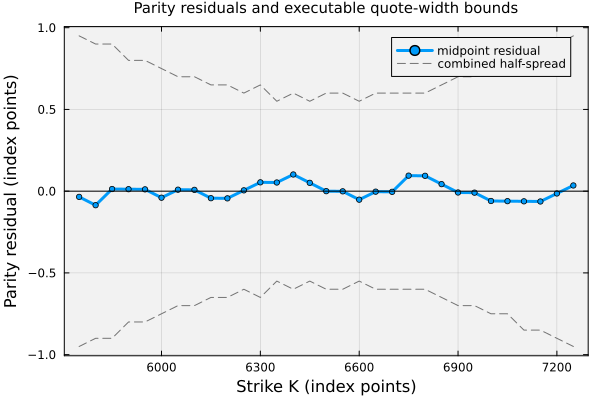

In [6]:
paired.parity_fitted = D̂ .* (F̂ .- paired.strike);
paired.parity_residual = parity_difference .- paired.parity_fitted;
paired.parity_halfspread = paired.call_halfspread .+ paired.put_halfspread;
paired.parity_within_spread = abs.(paired.parity_residual) .≤ paired.parity_halfspread;

parity_plot = plot(
    paired.strike, paired.parity_residual,
    lw=3, marker=:circle, ms=3, label="midpoint residual",
    xlabel="Strike K (index points)", ylabel="Parity residual (index points)",
    title="Parity residuals and executable quote-width bounds", titlefontsize=10,
    bg="gray95", background_color_outside="white", framestyle=:box
);
plot!(parity_plot, paired.strike, paired.parity_halfspread, ls=:dash, c=:gray45, label="combined half-spread");
plot!(parity_plot, paired.strike, -paired.parity_halfspread, ls=:dash, c=:gray45, label=false);
hline!(parity_plot, [0.0], c=:black, lw=1, label=false);
parity_plot

## Task 3: Invert forward-form BSM for implied volatility
Once $D(0,T)$ and $F_{0,T}$ are known, European BSM can be written without separately specifying spot and dividend yield:
$$
d_1=\frac{\ln(F_{0,T}/K)+\tfrac12\sigma^2T}{\sigma\sqrt{T}},\qquad d_2=d_1-\sigma\sqrt{T},
$$
$$
C=D(0,T)[F_{0,T}\Phi(d_1)-K\Phi(d_2)],
$$
$$
P=D(0,T)[K\Phi(-d_2)-F_{0,T}\Phi(-d_1)].
$$
Implied volatility is the value of $\sigma$ that reproduces an observed premium. It is a model coordinate, not an independently observed state variable. The bracketed bisection solver below is slower than Newton's method but robust because a vanilla European premium is increasing in volatility inside its no-arbitrage bounds.

In [7]:
function bsm_forward(option_type::AbstractString, F::Real, K::Real, T::Real, D::Real, σ::Real)
    option_type ∈ ("call", "put") || throw(ArgumentError("option_type must be call or put"))
    F > 0 && K > 0 && T > 0 && D > 0 && σ > 0 || throw(ArgumentError("invalid BSM input"))
    d₁ = (log(F/K) + 0.5*σ^2*T)/(σ*sqrt(T));
    d₂ = d₁ - σ*sqrt(T);
    N = Normal();
    return option_type == "call" ? D*(F*cdf(N,d₁) - K*cdf(N,d₂)) : D*(K*cdf(N,-d₂) - F*cdf(N,-d₁))
end

function implied_volatility(option_type::AbstractString, price::Real, F::Real, K::Real, T::Real, D::Real; lo=1e-6, hi=3.0, iterations=100)
    lower = option_type == "call" ? D*max(F-K,0.0) : D*max(K-F,0.0);
    upper = option_type == "call" ? D*F : D*K;
    lower - 1e-10 ≤ price ≤ upper + 1e-10 || throw(DomainError(price, "premium violates European bounds"))
    isapprox(price, lower; atol=1e-12) && return 0.0
    bsm_forward(option_type,F,K,T,D,hi) ≥ price || throw(DomainError(price, "volatility bracket is too small"))
    for _ in 1:iterations
        mid = (lo+hi)/2;
        if bsm_forward(option_type,F,K,T,D,mid) < price
            lo = mid;
        else
            hi = mid;
        end
    end
    return (lo+hi)/2
end

implied_volatility (generic function with 1 method)

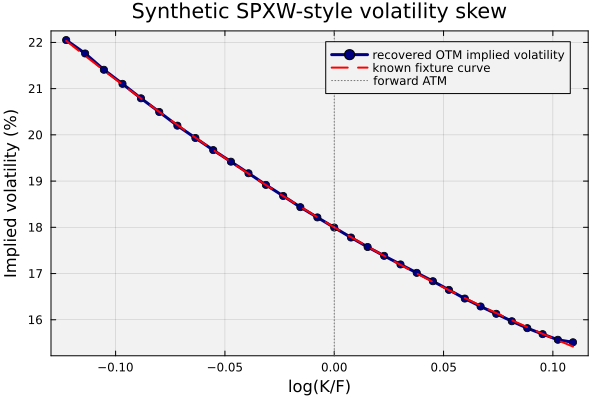

In [8]:
paired.log_forward_moneyness = log.(paired.strike./F̂);
paired.call_iv = [implied_volatility("call", paired.call_mid[i], F̂, paired.strike[i], T, D̂) for i in 1:nrow(paired)];
paired.put_iv = [implied_volatility("put", paired.put_mid[i], F̂, paired.strike[i], T, D̂) for i in 1:nrow(paired)];
paired.otm_iv = ifelse.(paired.strike .< F̂, paired.put_iv, paired.call_iv);
paired.fixture_iv = 0.18 .- 0.28.*paired.log_forward_moneyness .+ 0.40.*paired.log_forward_moneyness.^2;

skew_plot = plot(
    paired.log_forward_moneyness, 100 .* paired.otm_iv,
    lw=3, marker=:circle, ms=4, c=:navy, label="recovered OTM implied volatility",
    xlabel="log(K/F)", ylabel="Implied volatility (%)",
    title="Synthetic SPXW-style volatility skew",
    bg="gray95", background_color_outside="white", framestyle=:box
);
plot!(skew_plot, paired.log_forward_moneyness, 100 .* paired.fixture_iv, lw=2, ls=:dash, c=:red, label="known fixture curve");
vline!(skew_plot, [0.0], c=:gray45, ls=:dot, label="forward ATM");
skew_plot

In [9]:
sample_rows = 1:5:nrow(paired);
DataFrame(
    strike = paired.strike[sample_rows],
    log_K_over_F = round.(paired.log_forward_moneyness[sample_rows], digits=4),
    call_IV_percent = round.(100 .* paired.call_iv[sample_rows], digits=3),
    put_IV_percent = round.(100 .* paired.put_iv[sample_rows], digits=3),
    OTM_IV_percent = round.(100 .* paired.otm_iv[sample_rows], digits=3)
)

Row,strike,log_K_over_F,call_IV_percent,put_IV_percent,OTM_IV_percent
,Float64,Float64,Float64,Float64,Float64
1,5750.0,-0.1226,22.027,22.051,22.051
2,6000.0,-0.08,20.484,20.495,20.495
3,6250.0,-0.0392,19.17,19.169,19.169
4,6500.0,0.0,17.995,17.995,17.995
5,6750.0,0.0377,17.015,17.0,17.015
6,7000.0,0.0741,16.129,16.15,16.129
7,7250.0,0.1092,15.513,15.458,15.513


## Task 3b: Put implied volatility beside realized volatility
Implied volatility is inferred from today's option premium and is therefore forward-looking under a pricing model. Realized volatility is computed from past index returns and is backward-looking. The 20-day window is close to this contract's remaining trading horizon, while the 60-day window gives a slower-moving reference. Neither is a prediction, and neither should be expected to equal BSM implied volatility.

> __Source boundary:__ The horizontal ATM-IV line comes from the synthetic SPXW fixture. The historical curves come from Yahoo when available, otherwise from the labeled synthetic fallback. This plot compares dimensionless volatility magnitudes for teaching; it does not claim that the sources form one tradeable market snapshot.

Row,measure,annualized_percent,direction,source
,String,Float64,String,String
1,20-day realized,14.2,backward-looking,Yahoo Finance ^GSPC chart API
2,60-day realized,14.01,backward-looking,Yahoo Finance ^GSPC chart API
3,synthetic ATM implied,18.0,forward-looking model coordinate,synthetic SPXW fixture


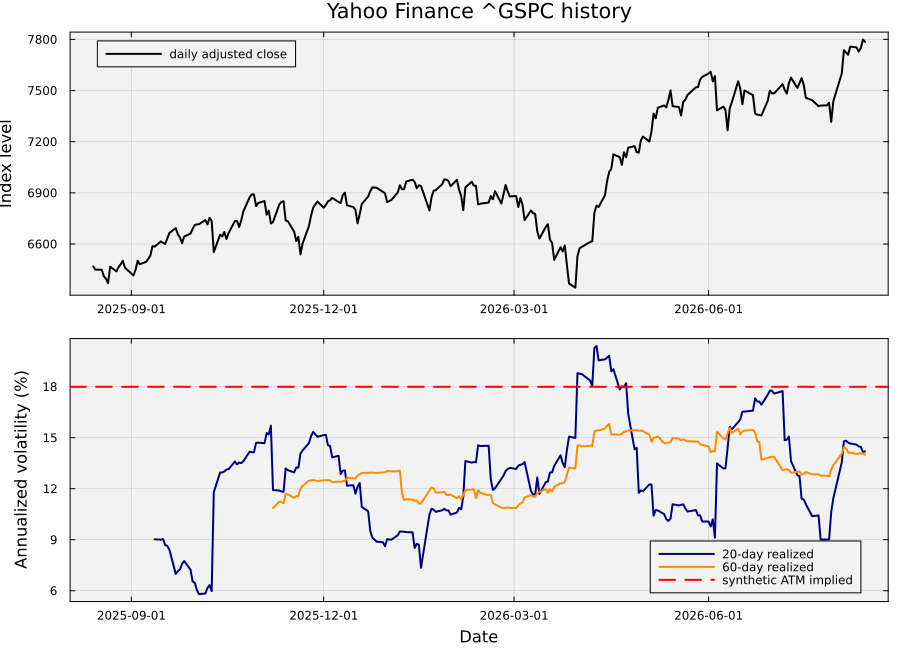

In [10]:
atm_index = argmin(abs.(paired.log_forward_moneyness));
atm_iv = paired.otm_iv[atm_index];
rv20_values = collect(skipmissing(spx_history.rv20));
rv60_values = collect(skipmissing(spx_history.rv60));
latest_rv20 = last(rv20_values);
latest_rv60 = last(rv60_values);

volatility_comparison = DataFrame(
    measure = ["20-day realized", "60-day realized", "synthetic ATM implied"],
    annualized_percent = round.(100 .* [latest_rv20, latest_rv60, atm_iv], digits=2),
    direction = ["backward-looking", "backward-looking", "forward-looking model coordinate"],
    source = [history_source, history_source, "synthetic SPXW fixture"]
);
display(volatility_comparison);

history_label = startswith(history_source, "Yahoo") ? "Yahoo Finance ^GSPC" : "Synthetic offline fallback";
price_plot = plot(
    spx_history.date, spx_history.close,
    lw=2, c=:black, label="daily adjusted close",
    ylabel="Index level", title=history_label * " history",
    bg="gray95", background_color_outside="white", framestyle=:box
);
volatility_plot = plot(
    spx_history.date, 100 .* spx_history.rv20,
    lw=2, c=:navy, label="20-day realized",
    xlabel="Date", ylabel="Annualized volatility (%)",
    bg="gray95", background_color_outside="white", framestyle=:box
);
plot!(volatility_plot, spx_history.date, 100 .* spx_history.rv60, lw=2, c=:darkorange, label="60-day realized");
hline!(volatility_plot, [100 * atm_iv], lw=2, ls=:dash, c=:red, label="synthetic ATM implied");
plot(price_plot, volatility_plot; layout=(2, 1), size=(900, 650))

### Interpreting the curve
The recovered curve slopes downward as strike rises: out-of-the-money puts on the left have higher implied volatility than out-of-the-money calls on the right. Calling this shape a __skew__ is descriptive; it does not mean the index has a different physical volatility for every strike. It means one constant-$\sigma$ lognormal BSM model cannot reproduce the entire premium cross-section at once.

Using out-of-the-money options is conventional because their quotes often have cleaner relative price information than deep-in-the-money options. Call and put implied volatilities at the same strike should nevertheless agree when the quote pair, forward, discount factor, and settlement inputs are internally consistent.

## Task 4: Run no-arbitrage and implementation checks
A visually smooth volatility curve does not validate a chain. The following checks operate on prices before interpreting implied volatility:

1. bids are nonnegative and asks are not below bids;
2. European premiums remain between discounted intrinsic value and their finite upper bounds;
3. parity residuals fit inside the combined call/put half-spread;
4. calls are nonincreasing and puts nondecreasing in strike;
5. equally spaced call and put premiums are discretely convex in strike; and
6. the implied-volatility solver reprices every midpoint.

These are necessary consistency checks under the stated conventions. They are not proof of an executable arbitrage without synchronized executable quotes, fees, position capacity, and settlement details.

In [11]:
call_lower = D̂ .* max.(F̂ .- paired.strike, 0.0);
put_lower = D̂ .* max.(paired.strike .- F̂, 0.0);
call_repriced = [bsm_forward("call",F̂,paired.strike[i],T,D̂,paired.call_iv[i]) for i in 1:nrow(paired)];
put_repriced = [bsm_forward("put",F̂,paired.strike[i],T,D̂,paired.put_iv[i]) for i in 1:nrow(paired)];

quote_order = all(chain.bid .≥ 0.0) && all(chain.ask .≥ chain.bid);
bounds_hold = all(paired.call_ask .≥ call_lower) && all(paired.call_bid .≤ D̂*F̂) &&
              all(paired.put_ask .≥ put_lower) && all(paired.put_bid .≤ D̂.*paired.strike);
parity_holds = all(paired.parity_within_spread);
monotonicity_holds = all(diff(paired.call_mid) .≤ 0.0) && all(diff(paired.put_mid) .≥ 0.0);
equal_spacing = all(isapprox.(diff(paired.strike), first(diff(paired.strike)); atol=1e-12));
convexity_holds = equal_spacing && all(diff(diff(paired.call_mid)) .≥ -1e-12) && all(diff(diff(paired.put_mid)) .≥ -1e-12);
repricing_error = max(maximum(abs.(call_repriced .- paired.call_mid)), maximum(abs.(put_repriced .- paired.put_mid)));
repricing_holds = repricing_error < 1e-8;

checks = DataFrame(
    check = ["quote ordering", "European price bounds", "parity within spreads", "strike monotonicity", "discrete convexity", "BSM repricing"],
    passed = [quote_order, bounds_hold, parity_holds, monotonicity_holds, convexity_holds, repricing_holds],
    diagnostic = [
        "minimum bid = $(minimum(chain.bid))",
        "no ask is below a lower bound; no bid exceeds an upper bound",
        "max |residual| = $(round(maximum(abs.(paired.parity_residual)), digits=6))",
        "calls down; puts up",
        "min call/put second differences = $(minimum(diff(diff(paired.call_mid)))) / $(minimum(diff(diff(paired.put_mid))))",
        "max absolute error = $(repricing_error)"
    ]
);
@assert all(checks.passed) "the option-chain audit failed"
pretty_table(checks; table_format=TextTableFormat(borders=text_table_borders__compact));
checks

 ----------------------- -------- ----------------------------------------------
                  check   passed                                               ⋯
                 String     Bool                                               ⋯
 ----------------------- -------- ----------------------------------------------
         quote ordering     true                                               ⋯
  European price bounds     true                 no ask is below a lower bound ⋯
  parity within spreads     true                                               ⋯
    strike monotonicity     true                                               ⋯
     discrete convexity     true   min call/put second differences = 0.3999999 ⋯
          BSM repricing     true                                   max absolut ⋯
 ----------------------- -------- ----------------------------------------------
                                                                1 column omitted


Row,check,passed,diagnostic
,String,Bool,String
1,quote ordering,true,minimum bid = 1.1
2,European price bounds,true,no ask is below a lower bound; no bid exceeds an upper bound
3,parity within spreads,true,max |residual| = 0.102016
4,strike monotonicity,true,calls down; puts up
5,discrete convexity,true,min call/put second differences = 0.3999999999999997 / 0.29999999999999893
6,BSM repricing,true,max absolute error = 9.094947017729282e-13


## Task 5: Convert index settlement into contract cash
SPXW is cash settled. If the official settlement index is $S_{\mathrm{settle}}$, the expiration cash flows for one contract with multiplier $q=100$ USD/index point are
$$
q(S_{\mathrm{settle}}-K)^+\quad\text{and}\quad q(K-S_{\mathrm{settle}})^+.
$$
No basket of 500 shares is delivered, and European exercise eliminates an early-assignment path. Settlement convention still matters: the relevant settlement index and its calculation time must match the exact series being valued.

In [12]:
K_example = 6500.0;
settlement_levels = [6400.0, 6500.0, 6600.0];
DataFrame(
    settlement_index = settlement_levels,
    call_cash_USD = contract_multiplier .* max.(settlement_levels .- K_example, 0.0),
    put_cash_USD = contract_multiplier .* max.(K_example .- settlement_levels, 0.0)
)

Row,settlement_index,call_cash_USD,put_cash_USD
,Float64,Float64,Float64
1,6400.0,0.0,10000.0
2,6500.0,0.0,0.0
3,6600.0,10000.0,0.0


## Replacing the fixture with permitted market data
A real snapshot can replace the bundled CSV without changing the analysis if it contains these columns:

| Column | Meaning |
|---|---|
| `contract_root` | Exact product root, such as `SPXW` |
| `as_of_et` | One timestamp, including time-zone offset |
| `expiration` | Contract expiration date |
| `settlement` | `AM` or `PM` for the exact series |
| `option_type` | `call` or `put` |
| `strike` | Strike in index points |
| `bid`, `ask` | Synchronized executable quote bounds in index points |
| `source` | Vendor and snapshot identifier |

Before substitution, verify the market-data license permits the intended classroom distribution. Preserve the raw snapshot, record the retrieval timestamp and vendor, select exactly one expiration and settlement convention, and never combine a live index level with option quotes captured at another time. For actual term-structure work, replace the scalar rate with an expiration-matched discount curve and repeat the parity fit separately for every expiration.

## Summary
This notebook treated a European option chain as a system of linked prices rather than a collection of unrelated quotes.

> __Key Takeaways:__
>
> * __Parity identifies the financing coordinates.__ Across strikes, $C-P$ is affine in $K$; its slope identifies the discount factor and its intercept identifies the forward index level.
> * __Implied volatility is an inverse-model coordinate.__ Each premium maps to the $\sigma$ that reproduces it under BSM. A skew shows that one constant volatility cannot fit the whole chain.
> * __Realized and implied volatility answer different questions.__ Yahoo index returns summarize the past; option premiums encode a forward-looking model coordinate. Comparing them is informative only when their horizons, timestamps, and source boundaries are explicit.
> * __Price checks come before curve interpretation.__ Bounds, executable parity intervals, monotonicity, convexity, and repricing catch convention and data problems that a polished volatility plot can hide.
> * __Contract mechanics remain part of valuation.__ SPXW-style claims are European and cash settled; settlement index, AM/PM convention, timestamp, and the 100 USD multiplier determine the actual cash flow.

L9b changes the exercise set and asks whether American flexibility raises value above the European benchmark. A separate future module can compare these option claims with binary event contracts such as Kalshi and with linear futures obligations without conflating their pricing logic.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. The option quote fixture is synthetic; the index-history cell reports whether it loaded Yahoo Finance history or the synthetic offline fallback. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Index-option valuation depends on model assumptions, quote quality, liquidity, settlement rules, financing inputs, dividends, fees, and position constraints. You are responsible for decisions based on your own circumstances, objectives, risk tolerance, and liquidity needs.
___